# Step 2 — Scaling Up with Tensor Networks

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 2 of 4 (Read-only)**

Coloring 4 regions with 16 qubits is small enough for exact state-vector
simulation. Now we color a finer map: the 19 main-island counties, grouped into **9 zones**
(each zone gets one color; every county inside a zone shares it). With 4 colors that makes
**9 × 4 = 36 qubits**, and the numbers stop being friendly:

- A state vector stores one complex number per bit pattern. For this 36-qubit problem, it requires $2^{36} \times 8$ bytes = **550 GB** — exceeds the memory capacity of most single GPUs available today.
- The `tensornet` simulator sidesteps the giant vector: it keeps the state as a web of small
  tensors and only combines ("contracts") what a measurement actually needs. Its cost depends on
  the circuit's *topology*, instead of the qubit count.

This notebook also designs a smarter circuit that builds the one-color-per-zone rule
directly into the quantum state — and the first thing it explains is why the familiar circuit
from notebooks 00–01 is not worth running at this size.

In [1]:
# Cell 1 — the 9-zone problem: 9 zones x 4 colors -> 36 qubits, on tensornet.
import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq

cudaq.set_random_seed(1234)
cudaq.set_target("tensornet", option="fp32")   # exact tensor-network simulator, defaults
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")

taiwan = hp.load_map()
NODES = hp.ZONE_ORDER                # the 9 zones (fixed order = qubit numbering)
EDGES = taiwan["zone_edges"]         # 14 zone borders, derived from real county borders
K = 4                                # colors
A, B = 8.0, 1.0                      # penalties: A >= (max degree 5)*B + 1
N = len(NODES) * K                   # 36 qubits

zones = hp.members_of(taiwan, "zone")
print(f"\n{len(NODES)} zones covering all {len(taiwan['counties'])} main-island counties:")
for zone in hp.ZONE_ORDER:
    print(f"  {zone}: {', '.join(zones[zone])}")

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)
print(f"\n{len(NODES)} zones x {K} colors = {N} qubits; "
      f"{len(terms['z'])} Z + {len(terms['zz'])} ZZ terms, constant offset {offset}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3

9 zones covering all 19 main-island counties:
  Taipei: Taipei City, New Taipei City
  Keelung: Keelung City
  Taoyuan-Hsinchu-Miaoli: Taoyuan City, Hsinchu City, Hsinchu County, Miaoli County
  Yilan: Yilan County
  Taichung-Changhua-Nantou: Taichung City, Changhua County, Nantou County
  Yunlin-Chiayi: Chiayi City, Yunlin County, Chiayi County
  Tainan: Tainan City
  South: Kaohsiung City, Pingtung County
  East: Hualien County, Taitung County

9 zones x 4 colors = 36 qubits; 36 Z + 110 ZZ terms, constant offset 158.0


## 1 · A circuit that encodes the rule

This notebook also designs a smarter circuit that builds the one-color-per-zone rule
directly into the quantum state, because plain QAOA with the standard
mixer would almost never sample a valid coloring at this size — the valid patterns are about
**1 in 30 million** of all $2^{36}$ bit patterns (exactly 2,304 among ≈ 69 billion). So we build
the one-color-per-zone rule into the circuit itself:

1. **W-state start.** Each zone's 4 qubits are prepared sharing a *single* "1" equally — a
   quantum state that already means "exactly one color, all four equally likely". The three
   rotation angles below do the equal splitting.
2. **XY ring mixer.** Instead of flipping qubits independently (which creates zero-color and
   two-color patterns), this mixer **swaps the single 1 around** inside each zone's 4 qubits.
   Every sample therefore automatically gives each zone exactly one color — only the
   neighbors-differ rule remains for the optimizer to work on.

The circuit uses only **one- and two-qubit gates** and is scored by the same Hamiltonian as any
other QAOA circuit for this problem.

In [2]:
# Cell 2 — the XY circuit.
# Angles that spread one "1" equally over a zone's 4 qubits (a W state):
# 2*arccos(1/2), 2*arccos(1/sqrt(3)), 2*arccos(1/sqrt(2)).
W_ANGLES = [2.0943951023931953, 1.9106332362490186, 1.5707963267948966]    # This can be used for notebook 03 and 04

@cudaq.kernel
def xy_kernel(n: int, zq: list[int], zc: list[float], zz1: list[int],
              zz2: list[int], zzc: list[float], wa: list[float],
              ra: list[int], rb: list[int], gammas: list[float], betas: list[float]):
    q = cudaq.qvector(n)
    for v in range(n // 4):                           # W-state start on each zone
        base = 4 * v
        x(q[base])
        for k in range(3):
            ry.ctrl(wa[k], q[base + k], q[base + k + 1])
            x.ctrl(q[base + k + 1], q[base + k])
    for layer in range(len(gammas)):
        for i in range(len(zq)):                      # cost layer: Z terms, then ZZ terms
            rz(2.0 * gammas[layer] * zc[i], q[zq[i]])
        for i in range(len(zz1)):
            x.ctrl(q[zz1[i]], q[zz2[i]])
            rz(2.0 * gammas[layer] * zzc[i], q[zz2[i]])
            x.ctrl(q[zz1[i]], q[zz2[i]])
        for i in range(len(ra)):                      # XY mixer: swap the "1" around the ring
            a = ra[i]
            b = rb[i]
            h(q[a])                                   # this block = exp(-i beta XX)
            h(q[b])
            x.ctrl(q[a], q[b])
            rz(2.0 * betas[layer], q[b])
            x.ctrl(q[a], q[b])
            h(q[a])
            h(q[b])
            rx(1.5707963267948966, q[a])              # this block = exp(-i beta YY)
            rx(1.5707963267948966, q[b])
            x.ctrl(q[a], q[b])
            rz(2.0 * betas[layer], q[b])
            x.ctrl(q[a], q[b])
            rx(-1.5707963267948966, q[a])
            rx(-1.5707963267948966, q[b])

ring_a, ring_b = [], []
for v in range(len(NODES)):                           # ring pairs (0-1, 1-2, 2-3, 3-0) per zone
    for a, b in [(0, 1), (1, 2), (2, 3), (3, 0)]:
        ring_a.append(4 * v + a)
        ring_b.append(4 * v + b)

def energy(params):
    return cudaq.observe(xy_kernel, H, N, zq, zc, zz1, zz2, zzc, W_ANGLES,
                         ring_a, ring_b, [params[0]], [params[1]]).expectation() + offset

## 2 · Optimize the XY circuit

The XY circuit starts already inside the one-color-per-zone world, where valid colorings are
common: exactly 2,304 of the $4^9 = 262{,}144$ one-color-per-zone patterns are valid — about
**0.9%** before any optimization. The optimizer's job is only to keep it there or push it higher
by discouraging same-color neighbors.

In [3]:
# Cell 3 — optimize the XY circuit: 5 evaluations (each one is expensive here).
num_iterations = 5
optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = [0.1, 0.1]
start = time.perf_counter()
best_xy, theta_star = optimizer.optimize(dimensions=2, function=energy)
t_opt_xy = time.perf_counter() - start
print(f"XY: best energy {best_xy:.4f} after {num_iterations} evaluations "
      f"({t_opt_xy:.0f} s — about {t_opt_xy / num_iterations:.0f} s per evaluation)")
print(f"best angles: gamma = {theta_star[0]:.4f}, beta = {theta_star[1]:.4f}")
print("(energies here are small numbers: the one-color rule is satisfied by design,")
print(" so only the neighbors-differ penalty contributes)")

XY: best energy 3.5004 after 5 evaluations (388 s — about 78 s per evaluation)
best angles: gamma = -1.4708, beta = 3.1416
(energies here are small numbers: the one-color rule is satisfied by design,
 so only the neighbors-differ penalty contributes)


## 3 · Sample the optimized XY circuit

Sampling is also priced per shot on a tensor-network simulator (each shot is its own small
contraction). At the optimized angles shots run about ten times faster than that,
and the cell prints the actual time. With a ~0.9% valid rate, roughly eighteen valid colorings
should appear — and the notebook's one check is that the best of them really is one.

In [4]:
# Cell 4 — sample, decode, and check (sampling only AFTER optimization).
SHOTS = 2000
start = time.perf_counter()
result = cudaq.sample(xy_kernel, N, zq, zc, zz1, zz2, zzc, W_ANGLES,
                      ring_a, ring_b, [theta_star[0]], [theta_star[1]], shots_count=SHOTS)
t_sample_xy = time.perf_counter() - start
counts_xy = {}
for bitstring, times_seen in result.items():
    counts_xy[bitstring] = times_seen
print(f"sampled {SHOTS:,} shots in {t_sample_xy:.0f} s")

summary = hp.summarize_samples(counts_xy, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid zone coloring.
assert summary["best"] is not None and hp.is_valid(summary["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid zone coloring (energy 0)")

sampled 2,000 shots in 19 s
valid colorings among raw samples: 21 / 2,000 shots = 1.0500%  (20 distinct bitstrings)
best valid coloring: '100000010100000100100001010010000100' (sampled 2 times, energy 0.0)
   Taipei=0, Keelung=3, Taoyuan-Hsinchu-Miaoli=1, Yilan=3, Taichung-Changhua-Nantou=2, Yunlin-Chiayi=3, Tainan=1, South=0, East=1
check passed: the best sampled bitstring is a valid zone coloring (energy 0)


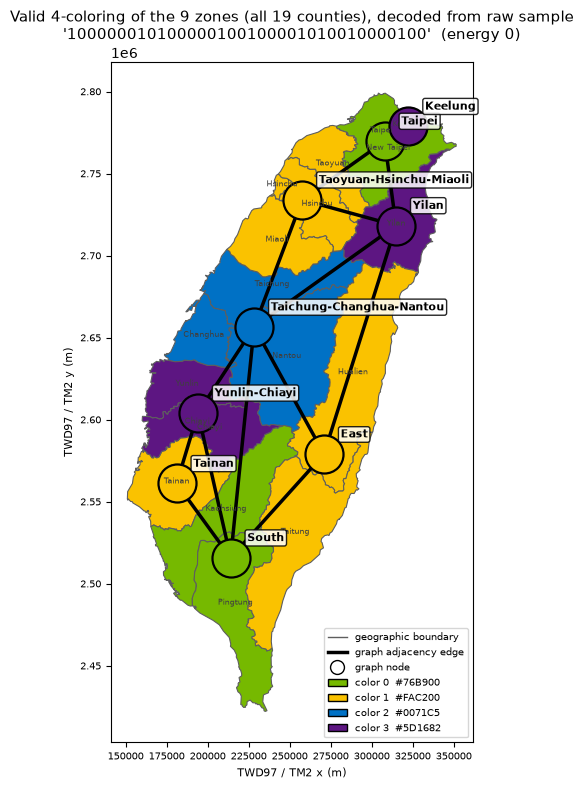

In [5]:
# Cell 5 — visualize on the map for the coloring.
best_coloring = summary["assignment"]            # e.g. {"Taipei": 2, "Keelung": 0, ...}
unit_colors = {}
for name, county in taiwan["counties"].items():  # every county wears its zone's color
    unit_colors[name] = hp.PALETTE[best_coloring[county["zone"]]]
node_colors = {}
for zone in hp.ZONE_ORDER:
    node_colors[zone] = hp.PALETTE[best_coloring[zone]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "zone"),
                      edges=EDGES, node_colors=node_colors,
                      unit_labels=True, color_legend=True,
                      title="Valid 4-coloring of the 9 zones (all 19 counties), decoded from "
                            f"raw sample\n'{summary['best']}'  (energy 0)")
plt.show()

## 4 · What you should take away

1. **State vectors have a hard wall.** $2^{36} \times 8$ bytes = 550 GB. Tensor networks trade that memory wall for a *time* cost that
   depends on circuit structure — measured honestly here at tens of seconds per energy
   evaluation.
2. **Encode what you know.** Plain QAOA would spread its amplitude over all $2^{36}$ patterns,
   of which only about 1 in 30 million is a valid coloring. The XY circuit starts inside the
   one-color-per-zone world — same Hamiltonian, same optimizer, and valid colorings appear
   immediately even from a tiny budget. Choosing a circuit that respects the problem's structure is the single biggest
   lever in this whole series.